In [45]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/datasets/rohan0301/unsupervised-learning-on-country-data/Country-data.csv
/kaggle/input/datasets/rohan0301/unsupervised-learning-on-country-data/data-dictionary.csv


In [46]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans, AgglomerativeClustering, DBSCAN
from sklearn.mixture import GaussianMixture
from sklearn.metrics import silhouette_score
from sklearn.neighbors import NearestNeighbors
from scipy.cluster.hierarchy import dendrogram, linkage

In [47]:
import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub

/kaggle/input/datasets/rohan0301/unsupervised-learning-on-country-data/Country-data.csv
/kaggle/input/datasets/rohan0301/unsupervised-learning-on-country-data/data-dictionary.csv


In [48]:
import os
print(os.listdir('/kaggle/input'))

['datasets']


In [49]:
import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

/kaggle/input/datasets/rohan0301/unsupervised-learning-on-country-data/Country-data.csv
/kaggle/input/datasets/rohan0301/unsupervised-learning-on-country-data/data-dictionary.csv


In [50]:
import pandas as pd

df = pd.read_csv("/kaggle/input/datasets/rohan0301/unsupervised-learning-on-country-data/Country-data.csv")
df.head(20)

,country,child_mort,exports,health,imports,income,inflation,life_expec,total_fer,gdpp
0,Afghanistan,90.2,10.0,7.58,44.9,1610,9.440,56.2,5.82,553
1,Albania,16.6,28.0,6.55,48.6,9930,4.490,76.3,1.65,4090
2,Algeria,27.3,38.4,4.17,31.4,12900,16.100,76.5,2.89,4460
3,Angola,119.0,62.3,2.85,42.9,5900,22.400,60.1,6.16,3530
4,Antigua and Barbuda,10.3,45.5,6.03,58.9,19100,1.440,76.8,2.13,12200
5,Argentina,14.5,18.9,8.10,16.0,18700,20.900,75.8,2.37,10300
6,Armenia,18.1,20.8,4.40,45.3,6700,7.770,73.3,1.69,3220
7,Australia,4.8,19.8,8.73,20.9,41400,1.160,82.0,1.93,51900
8,Austria,4.3,51.3,11.00,47.8,43200,0.873,80.5,1.44,46900
9,Azerbaijan,39.2,54.3,5.88,20.7,16000,13.800,69.1,1.92,5840


In [51]:
print("Shape:", df.shape)
print("\nData types:\n", df.dtypes)
print("\nMissing values:\n", df.isnull().sum())
print("\nDuplicate rows:", df.duplicated().sum())
print("\nStatistical summary:\n", df.describe().T)

Shape: (167, 10)

Data types:
 country        object
child_mort    float64
exports       float64
health        float64
imports       float64
income          int64
inflation     float64
life_expec    float64
total_fer     float64
gdpp            int64
dtype: object

Missing values:
 country       0
child_mort    0
exports       0
health        0
imports       0
income        0
inflation     0
life_expec    0
total_fer     0
gdpp          0
dtype: int64

Duplicate rows: 0

Statistical summary:
             count          mean           std       min       25%      50%  \
child_mort  167.0     38.270060     40.328931    2.6000     8.250    19.30   
exports     167.0     41.108976     27.412010    0.1090    23.800    35.00   
health      167.0      6.815689      2.746837    1.8100     4.920     6.32   
imports     167.0     46.890215     24.209589    0.0659    30.200    43.30   
income      167.0  17144.688623  19278.067698  609.0000  3355.000  9960.00   
inflation   167.0      7.781832   

Skewness:
 child_mort    1.450774
exports       2.445824
health        0.705746
imports       1.905276
income        2.231480
inflation     5.154049
life_expec   -0.970996
total_fer     0.967092
gdpp          2.218051
dtype: float64


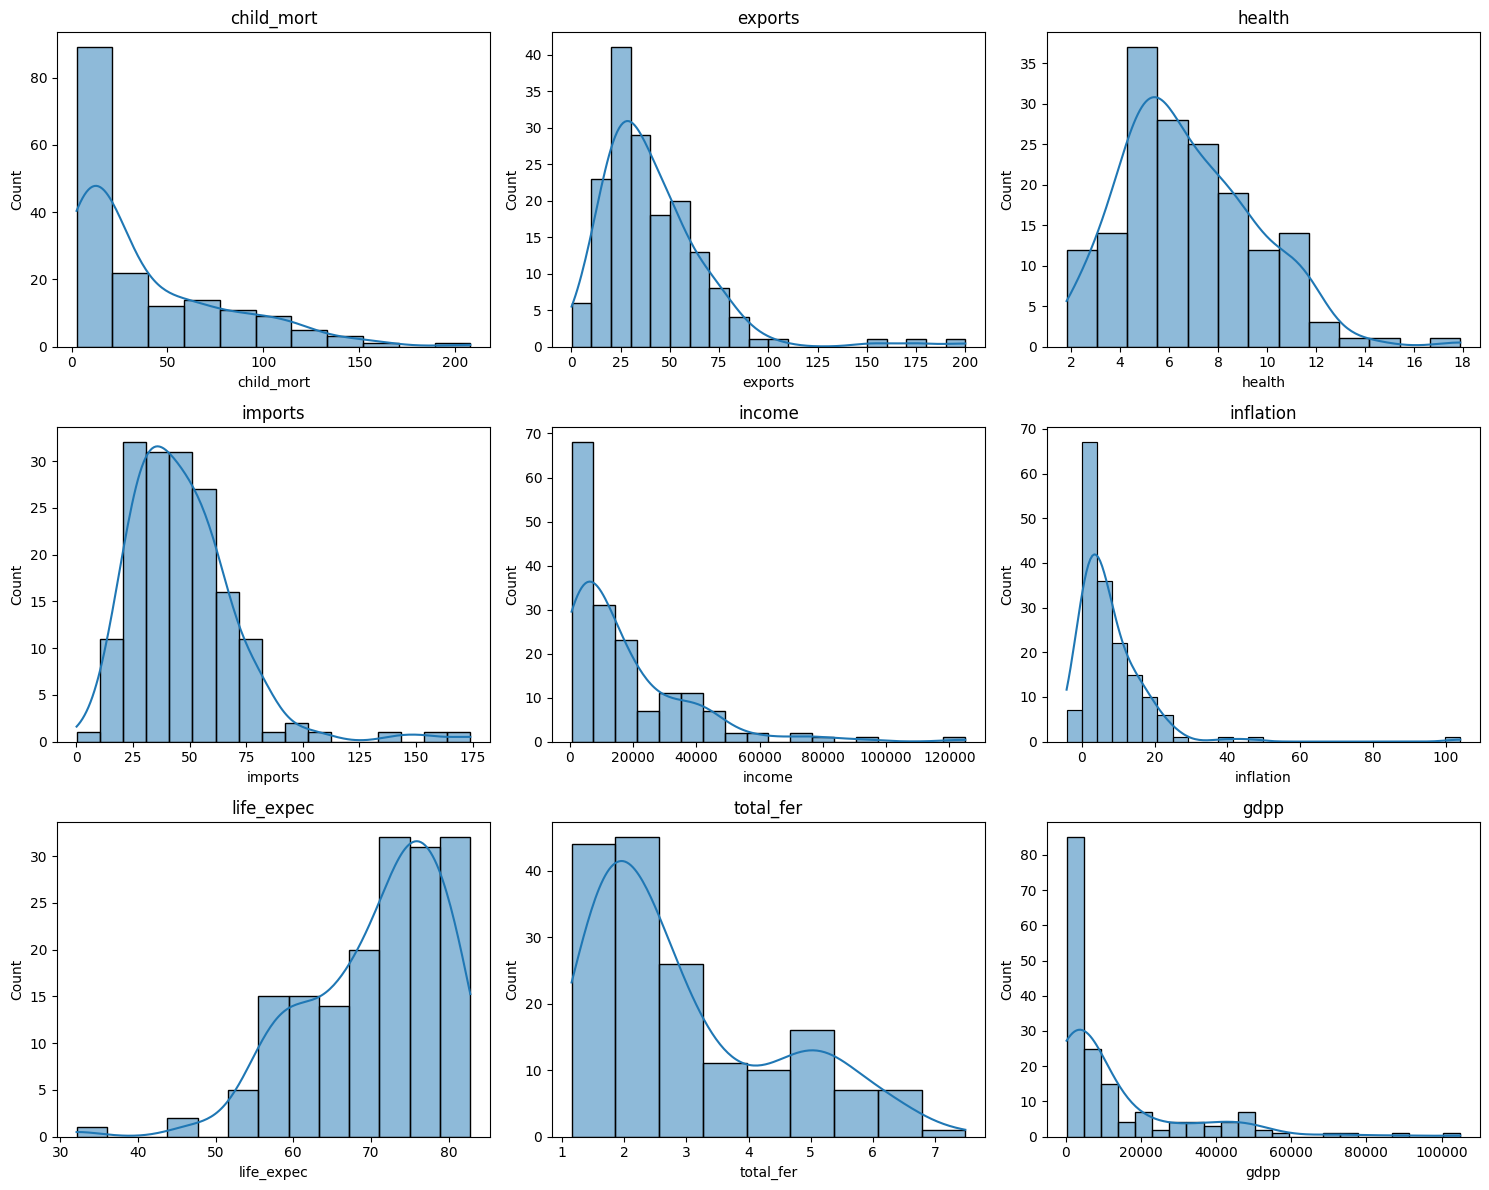

In [52]:
numeric_cols = df.columns.drop('country')

# Skewness
print("Skewness:\n", df[numeric_cols].skew())

# Histograms
fig, axes = plt.subplots(3, 3, figsize=(15, 12))
axes = axes.flatten()
for i, col in enumerate(numeric_cols):
    sns.histplot(df[col], kde=True, ax=axes[i])
    axes[i].set_title(col)
plt.tight_layout()
plt.show()

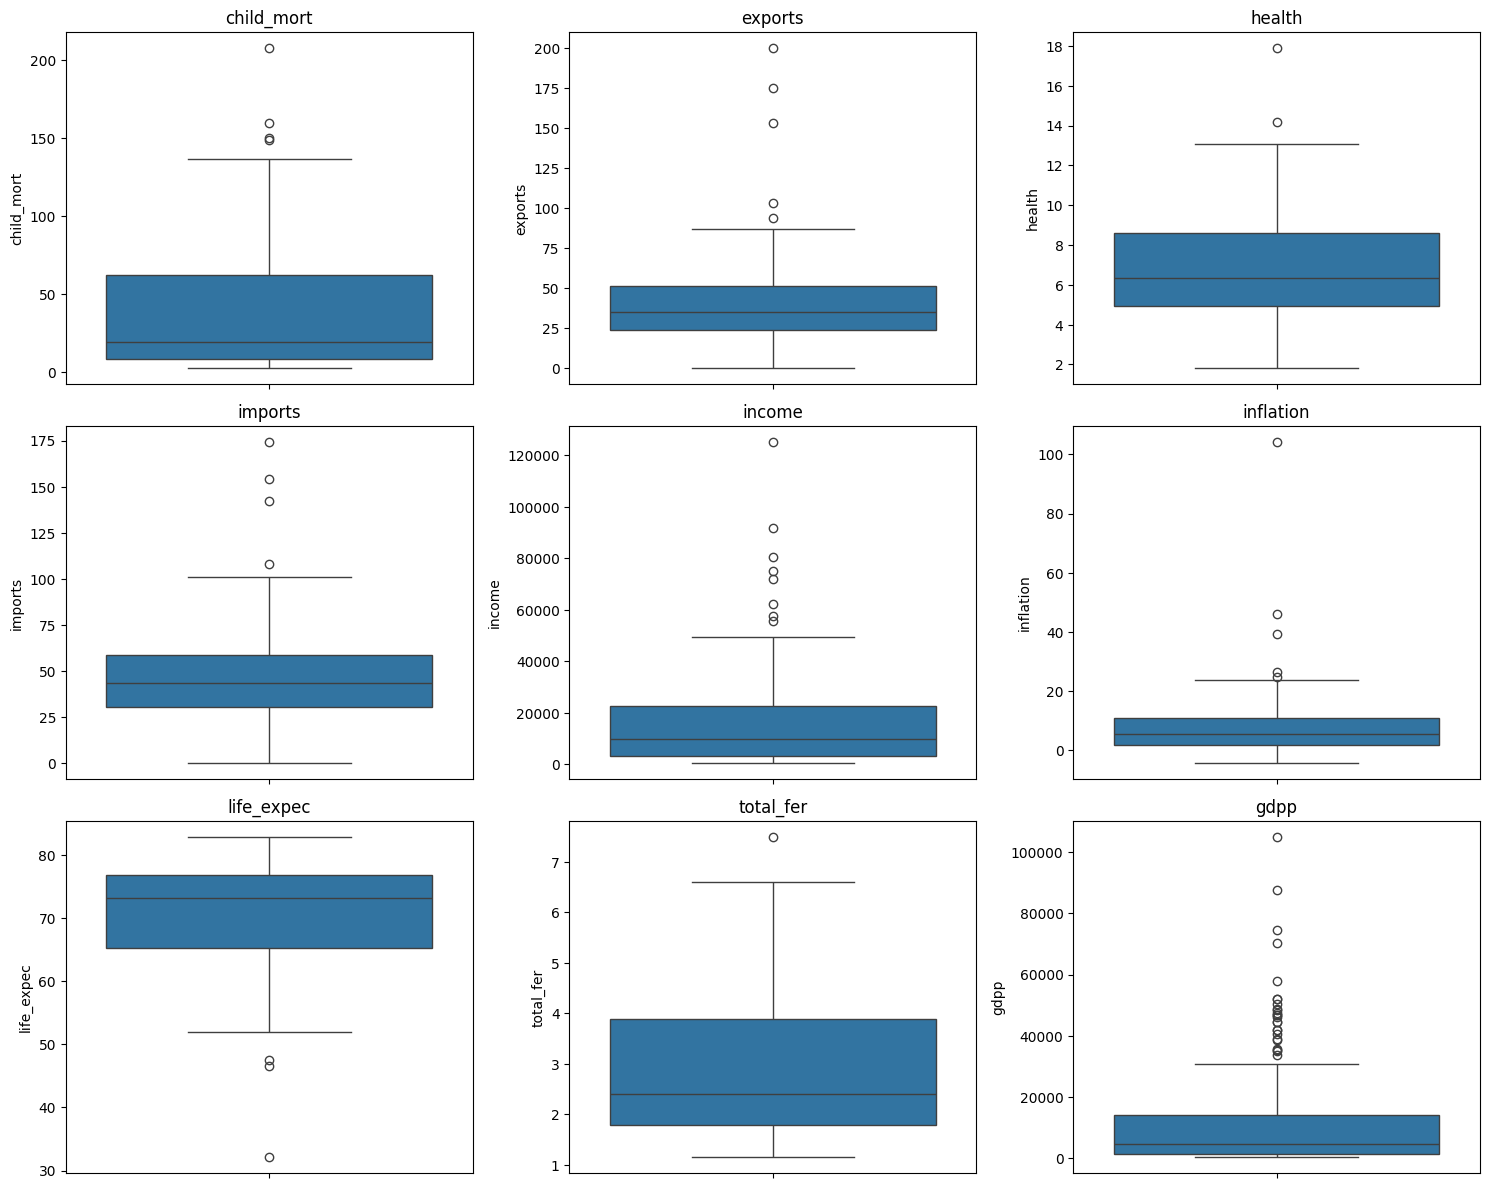

Outlier counts (IQR method):

child_mort: 4 outliers
exports: 5 outliers
health: 2 outliers
imports: 4 outliers
income: 8 outliers
inflation: 5 outliers
life_expec: 3 outliers
total_fer: 1 outliers
gdpp: 25 outliers


In [53]:
fig, axes = plt.subplots(3, 3, figsize=(15, 12))
axes = axes.flatten()
for i, col in enumerate(numeric_cols):
    sns.boxplot(y=df[col], ax=axes[i])
    axes[i].set_title(col)
plt.tight_layout()
plt.show()


print("Outlier counts (IQR method):\n")
for col in numeric_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    outliers = df[(df[col] < lower) | (df[col] > upper)]
    print(f"{col}: {len(outliers)} outliers")

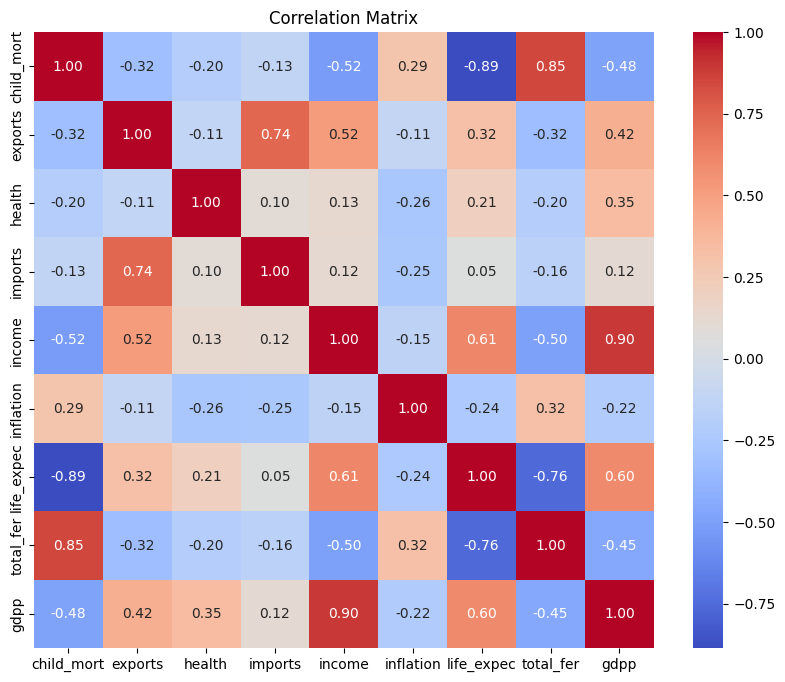

Top 5 - Highest child mortality (likely need aid):
                      country  child_mort  income  gdpp  life_expec
66                      Haiti       208.0    1500   662        32.1
132              Sierra Leone       160.0    1220   399        55.0
32                       Chad       150.0    1930   897        56.5
31   Central African Republic       149.0     888   446        47.5
97                       Mali       137.0    1870   708        59.5

Top 5 - Lowest income (likely need aid):
                      country  income  child_mort  gdpp  life_expec
37           Congo, Dem. Rep.     609       116.0   334        57.5
88                    Liberia     700        89.3   327        60.8
26                    Burundi     764        93.6   231        57.7
112                     Niger     814       123.0   348        58.8
31   Central African Republic     888       149.0   446        47.5

Top 5 - Lowest gdpp (likely need aid):
              country  gdpp  income  child_mort
26 

In [54]:
plt.figure(figsize=(10, 8))
sns.heatmap(df[numeric_cols].corr(), annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Correlation Matrix")
plt.show()


print("Top 5 - Highest child mortality (likely need aid):")
print(df.nlargest(5, 'child_mort')[['country', 'child_mort', 'income', 'gdpp', 'life_expec']])

print("\nTop 5 - Lowest income (likely need aid):")
print(df.nsmallest(5, 'income')[['country', 'income', 'child_mort', 'gdpp', 'life_expec']])

print("\nTop 5 - Lowest gdpp (likely need aid):")
print(df.nsmallest(5, 'gdpp')[['country', 'gdpp', 'income', 'child_mort']])

print("\nTop 5 - Highest income (developed):")
print(df.nlargest(5, 'income')[['country', 'income', 'gdpp', 'child_mort']])

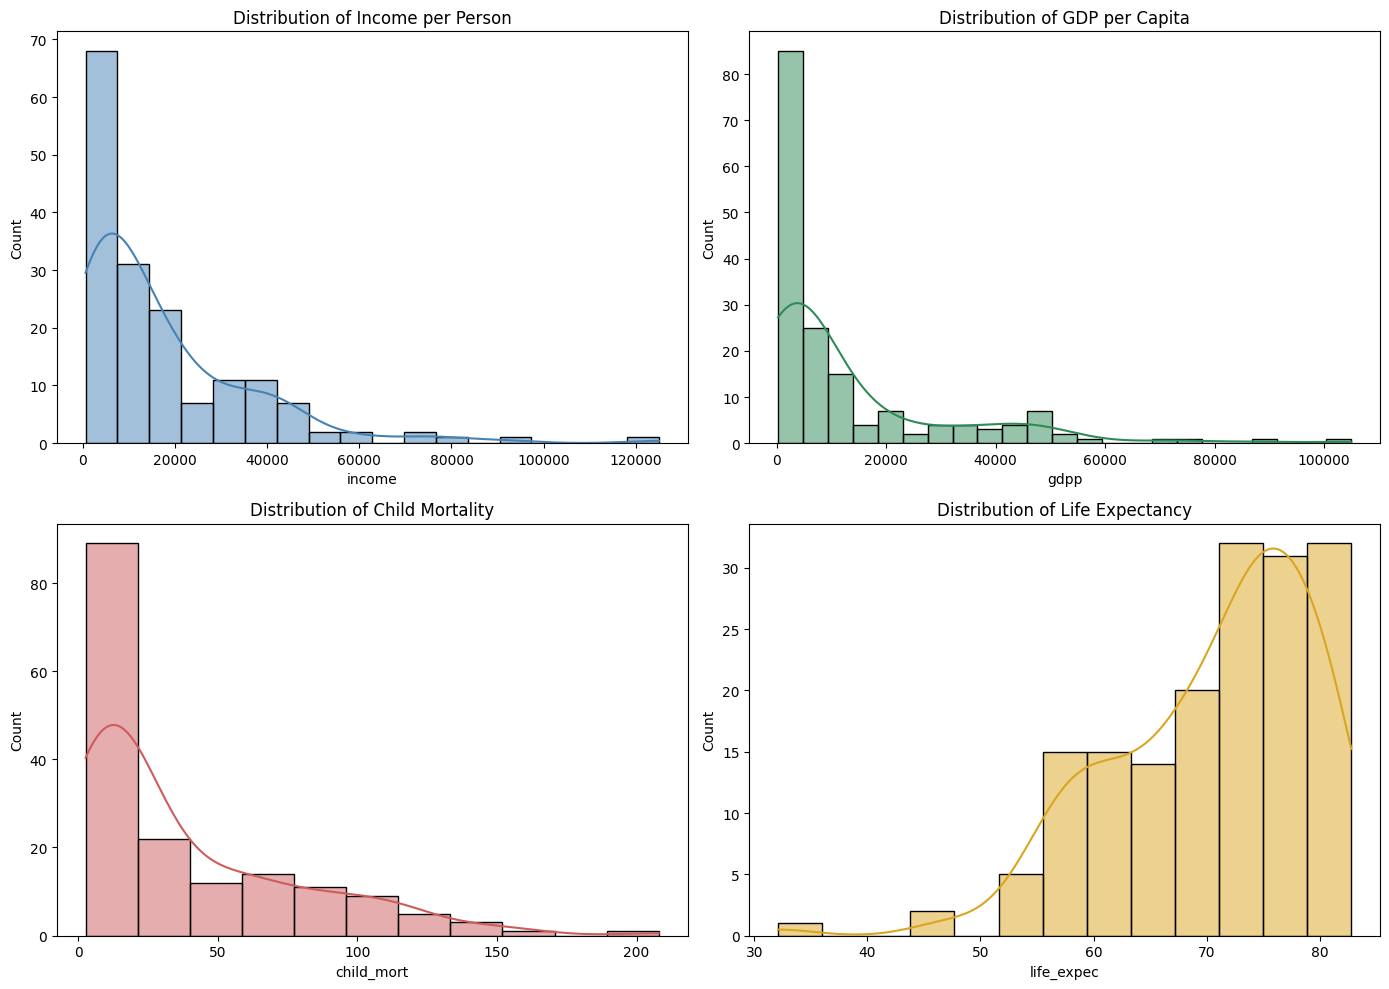

In [55]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

sns.histplot(df['income'], kde=True, ax=axes[0,0], color='steelblue')
axes[0,0].set_title('Distribution of Income per Person')

sns.histplot(df['gdpp'], kde=True, ax=axes[0,1], color='seagreen')
axes[0,1].set_title('Distribution of GDP per Capita')

sns.histplot(df['child_mort'], kde=True, ax=axes[1,0], color='indianred')
axes[1,0].set_title('Distribution of Child Mortality')

sns.histplot(df['life_expec'], kde=True, ax=axes[1,1], color='goldenrod')
axes[1,1].set_title('Distribution of Life Expectancy')

plt.tight_layout()
plt.show()

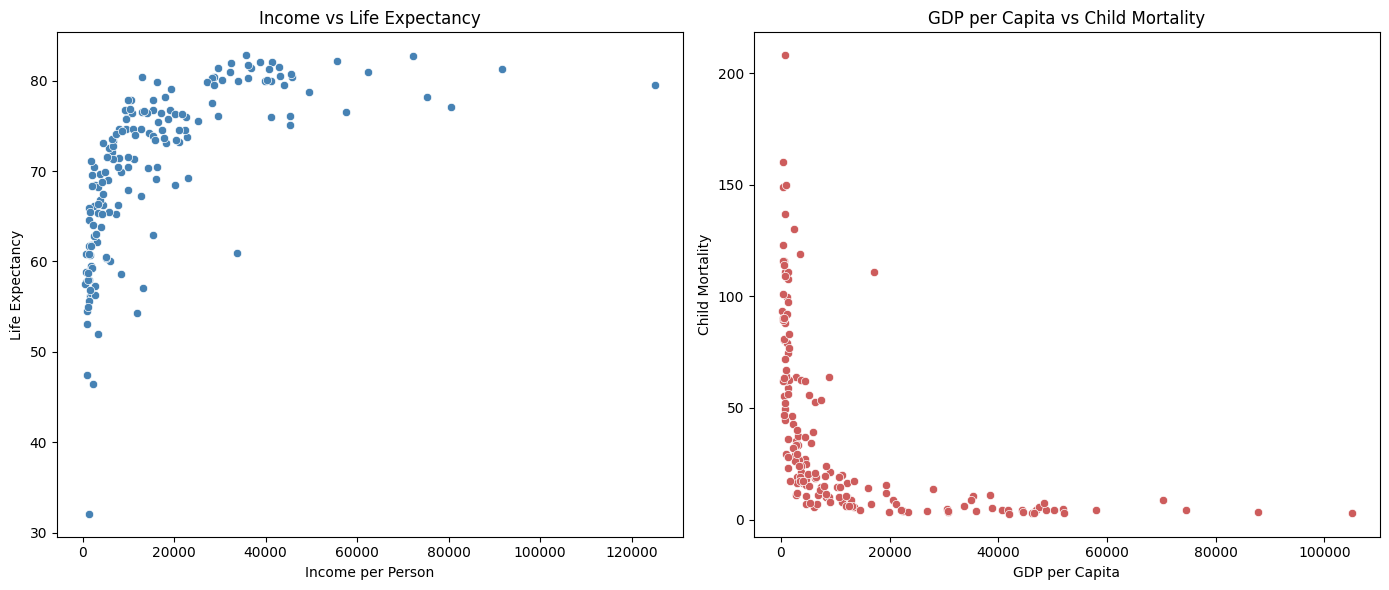

In [56]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

sns.scatterplot(data=df, x='income', y='life_expec', ax=axes[0], color='steelblue')
axes[0].set_title('Income vs Life Expectancy')
axes[0].set_xlabel('Income per Person')
axes[0].set_ylabel('Life Expectancy')

sns.scatterplot(data=df, x='gdpp', y='child_mort', ax=axes[1], color='indianred')
axes[1].set_title('GDP per Capita vs Child Mortality')
axes[1].set_xlabel('GDP per Capita')
axes[1].set_ylabel('Child Mortality')

plt.tight_layout()
plt.show()

In [57]:
from sklearn.preprocessing import StandardScaler


country_names = df['country']
X = df.drop(columns=['country'])

# Scale features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
X_scaled = pd.DataFrame(X_scaled, columns=X.columns)

print("Scaled data sample:\n", X_scaled.head())
print("\nMean after scaling (should be ~0):\n", X_scaled.mean().round(2))
print("\nStd after scaling (should be ~1):\n", X_scaled.std().round(2))

Scaled data sample:
    child_mort   exports    health   imports    income  inflation  life_expec  \
0    1.291532 -1.138280  0.279088 -0.082455 -0.808245   0.157336   -1.619092   
1   -0.538949 -0.479658 -0.097016  0.070837 -0.375369  -0.312347    0.647866   
2   -0.272833 -0.099122 -0.966073 -0.641762 -0.220844   0.789274    0.670423   
3    2.007808  0.775381 -1.448071 -0.165315 -0.585043   1.387054   -1.179234   
4   -0.695634  0.160668 -0.286894  0.497568  0.101732  -0.601749    0.704258   

   total_fer      gdpp  
0   1.902882 -0.679180  
1  -0.859973 -0.485623  
2  -0.038404 -0.465376  
3   2.128151 -0.516268  
4  -0.541946 -0.041817  

Mean after scaling (should be ~0):
 child_mort   -0.0
exports       0.0
health        0.0
imports       0.0
income       -0.0
inflation    -0.0
life_expec    0.0
total_fer     0.0
gdpp          0.0
dtype: float64

Std after scaling (should be ~1):
 child_mort    1.0
exports       1.0
health        1.0
imports       1.0
income        1.0
inflatio

Explained Variance Ratio per component:
 [0.46  0.172 0.13  0.111 0.073 0.025 0.013 0.01  0.007]

Cumulative Explained Variance:
 [0.46  0.631 0.761 0.872 0.945 0.97  0.983 0.993 1.   ]


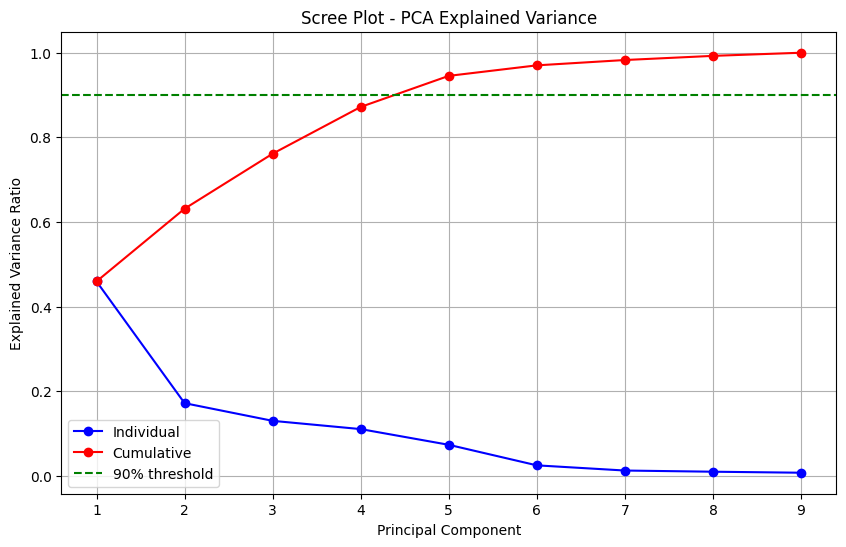

In [58]:
from sklearn.decomposition import PCA


pca = PCA()
pca.fit(X_scaled)


explained_var = pca.explained_variance_ratio_
cumulative_var = np.cumsum(explained_var)

print("Explained Variance Ratio per component:\n", explained_var.round(3))
print("\nCumulative Explained Variance:\n", cumulative_var.round(3))


plt.figure(figsize=(10, 6))
plt.plot(range(1, len(explained_var)+1), explained_var, 'bo-', label='Individual')
plt.plot(range(1, len(cumulative_var)+1), cumulative_var, 'ro-', label='Cumulative')
plt.axhline(y=0.90, color='g', linestyle='--', label='90% threshold')
plt.xlabel('Principal Component')
plt.ylabel('Explained Variance Ratio')
plt.title('Scree Plot - PCA Explained Variance')
plt.legend()
plt.grid(True)
plt.show()

Component Loadings:
               PC1    PC2    PC3
child_mort -0.420  0.193 -0.030
exports     0.284  0.613  0.145
health      0.151 -0.243 -0.597
imports     0.161  0.672 -0.300
income      0.398  0.023  0.302
inflation  -0.193 -0.008  0.643
life_expec  0.426 -0.223  0.114
total_fer  -0.404  0.155  0.020
gdpp        0.393 -0.046  0.123


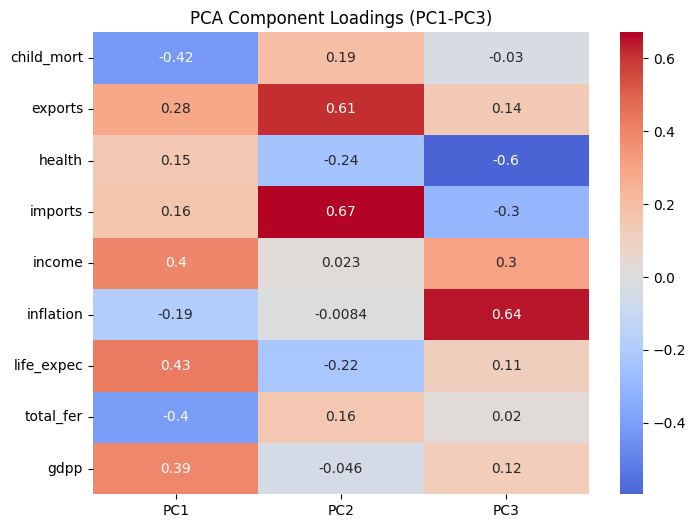

In [59]:
loadings = pd.DataFrame(
    pca.components_[:3].T,
    columns=['PC1', 'PC2', 'PC3'],
    index=X.columns
)
print("Component Loadings:\n", loadings.round(3))


plt.figure(figsize=(8, 6))
sns.heatmap(loadings, annot=True, cmap='coolwarm', center=0)
plt.title("PCA Component Loadings (PC1-PC3)")
plt.show()

In [60]:
pca_final = PCA(n_components=3)
pca_components = pca_final.fit_transform(X_scaled)

df_pca = pd.DataFrame(pca_components, columns=['PC1', 'PC2', 'PC3'])
df_pca['country'] = country_names.values

print("PCA-transformed data sample:\n", df_pca.head())


print("\nLowest PC1 (least developed - top aid candidates):")
print(df_pca.nsmallest(10, 'PC1')[['country', 'PC1']])

print("\nHighest PC1 (most developed):")
print(df_pca.nlargest(5, 'PC1')[['country', 'PC1']])

PCA-transformed data sample:
         PC1       PC2       PC3              country
0 -2.913025  0.095621 -0.718118          Afghanistan
1  0.429911 -0.588156 -0.333486              Albania
2 -0.285225 -0.455174  1.221505              Algeria
3 -2.932423  1.695555  1.525044               Angola
4  1.033576  0.136659 -0.225721  Antigua and Barbuda

Lowest PC1 (least developed - top aid candidates):
                      country       PC1
113                   Nigeria -4.912066
66                      Haiti -4.409717
31   Central African Republic -3.964964
32                       Chad -3.557555
112                     Niger -3.450168
97                       Mali -3.412255
132              Sierra Leone -3.381625
37           Congo, Dem. Rep. -3.173370
25               Burkina Faso -3.122053
94                     Malawi -2.979885

Highest PC1 (most developed):
         country       PC1
91    Luxembourg  6.917755
133    Singapore  5.783376
123        Qatar  4.242296
145  Switzerland  4.0

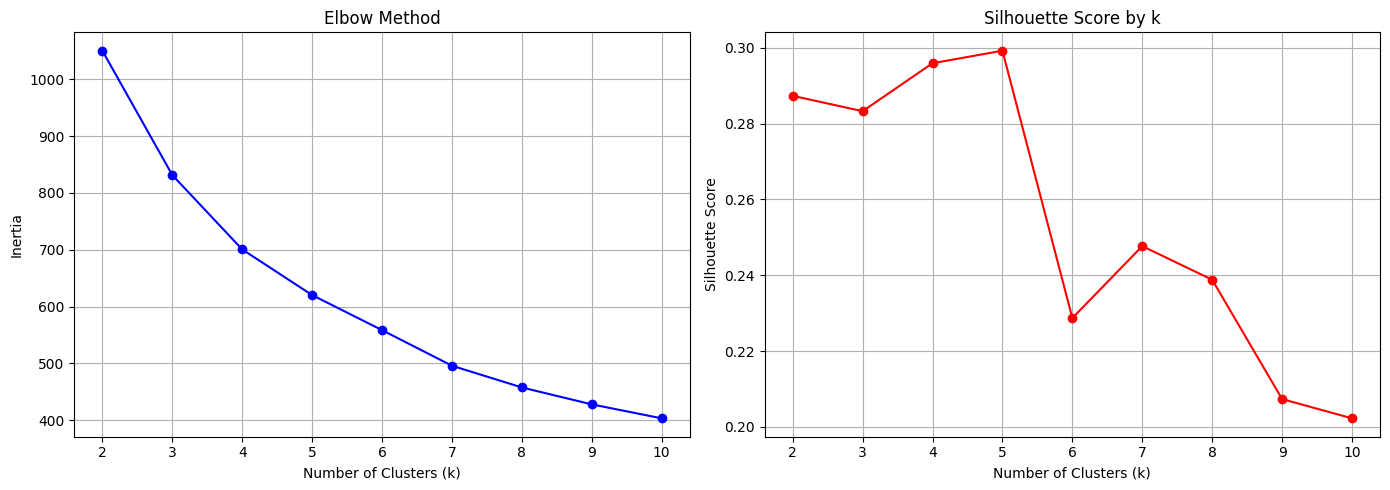

Inertia values:
 {2: np.float64(1050.2), 3: np.float64(831.4), 4: np.float64(700.5), 5: np.float64(620.2), 6: np.float64(558.5), 7: np.float64(495.8), 8: np.float64(457.6), 9: np.float64(427.8), 10: np.float64(403.2)}

Silhouette scores:
 {2: np.float64(0.287), 3: np.float64(0.283), 4: np.float64(0.296), 5: np.float64(0.299), 6: np.float64(0.229), 7: np.float64(0.248), 8: np.float64(0.239), 9: np.float64(0.207), 10: np.float64(0.202)}


In [61]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

inertia = []
silhouette_scores = []
K_range = range(2, 11)

for k in K_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(X_scaled)
    inertia.append(km.inertia_)
    silhouette_scores.append(silhouette_score(X_scaled, labels))


fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].plot(K_range, inertia, 'bo-')
axes[0].set_xlabel('Number of Clusters (k)')
axes[0].set_ylabel('Inertia')
axes[0].set_title('Elbow Method')
axes[0].grid(True)

axes[1].plot(K_range, silhouette_scores, 'ro-')
axes[1].set_xlabel('Number of Clusters (k)')
axes[1].set_ylabel('Silhouette Score')
axes[1].set_title('Silhouette Score by k')
axes[1].grid(True)
plt.tight_layout()
plt.show()

print("Inertia values:\n", dict(zip(K_range, np.round(inertia, 1))))
print("\nSilhouette scores:\n", dict(zip(K_range, np.round(silhouette_scores, 3))))

Cluster sizes:
 cluster
2    84
1    47
0    36
Name: count, dtype: int64

Cluster Centers (original scale):
          child_mort  exports  health  imports    income  inflation  \
cluster                                                              
0              5.00    58.74    8.81    51.49  45672.22       2.67   
1             92.96    29.15    6.39    42.32   3942.40      12.02   
2             21.93    40.24    6.20    47.47  12305.60       7.60   

         life_expec  total_fer      gdpp  
cluster                                   
0             80.13       1.75  42494.44  
1             59.19       5.01   1922.38  
2             72.81       2.31   6486.45  


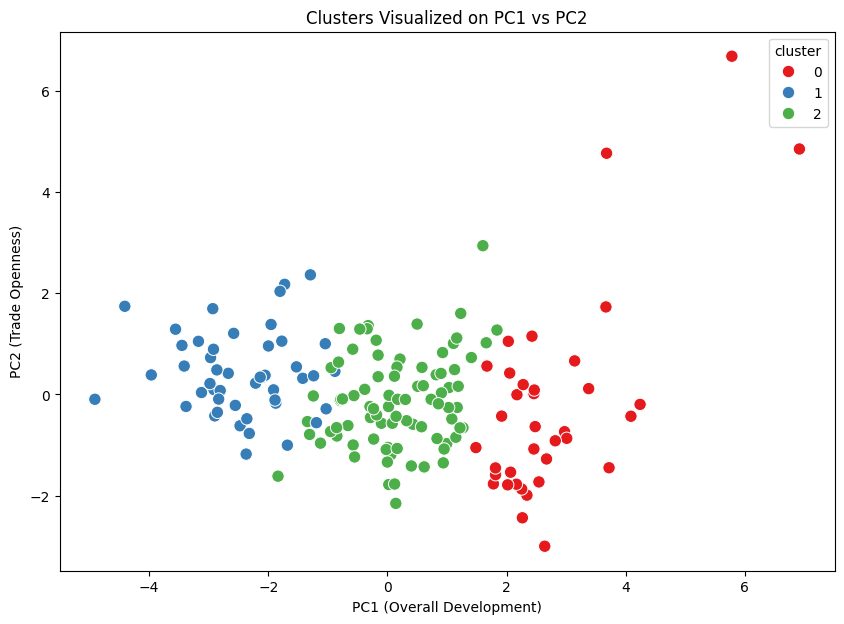

In [62]:
kmeans_final = KMeans(n_clusters=3, random_state=42, n_init=10)
df['cluster'] = kmeans_final.fit_predict(X_scaled)


df_pca['cluster'] = df['cluster'].values


print("Cluster sizes:\n", df['cluster'].value_counts())


centers_scaled = kmeans_final.cluster_centers_
centers_original = scaler.inverse_transform(centers_scaled)
centers_df = pd.DataFrame(centers_original, columns=X.columns)
centers_df.index.name = 'cluster'
print("\nCluster Centers (original scale):\n", centers_df.round(2))


plt.figure(figsize=(10, 7))
sns.scatterplot(data=df_pca, x='PC1', y='PC2', hue='cluster', palette='Set1', s=80)
plt.title('Clusters Visualized on PC1 vs PC2')
plt.xlabel('PC1 (Overall Development)')
plt.ylabel('PC2 (Trade Openness)')
plt.show()

In [63]:
cluster_profile = df.groupby('cluster')[[
    'child_mort', 'income', 'gdpp', 'life_expec', 'total_fer', 'inflation'
]].mean().round(2)

print(cluster_profile)

         child_mort    income      gdpp  life_expec  total_fer  inflation
cluster                                                                  
0              5.00  45672.22  42494.44       80.13       1.75       2.67
1             92.96   3942.40   1922.38       59.19       5.01      12.02
2             21.93  12305.60   6486.45       72.81       2.31       7.60


Cluster Summary (raw):
          child_mort    income      gdpp  life_expec  total_fer  inflation
cluster                                                                  
0              5.00  45672.22  42494.44       80.13       1.75       2.67
1             92.96   3942.40   1922.38       59.19       5.01      12.02
2             21.93  12305.60   6486.45       72.81       2.31       7.60

Tier Distribution:
 development_tier
Developing (Medium Priority)      84
Underdeveloped (High Priority)    47
Developed (Low Priority)          36
Name: count, dtype: int64

Total countries needing high-priority aid: 47

Top 15 most critical (lowest gdpp within priority cluster):
                      country  child_mort  income  gdpp  life_expec  \
26                    Burundi        93.6     764   231        57.7   
88                    Liberia        89.3     700   327        60.8   
37           Congo, Dem. Rep.       116.0     609   334        57.5   
112                     Niger       123

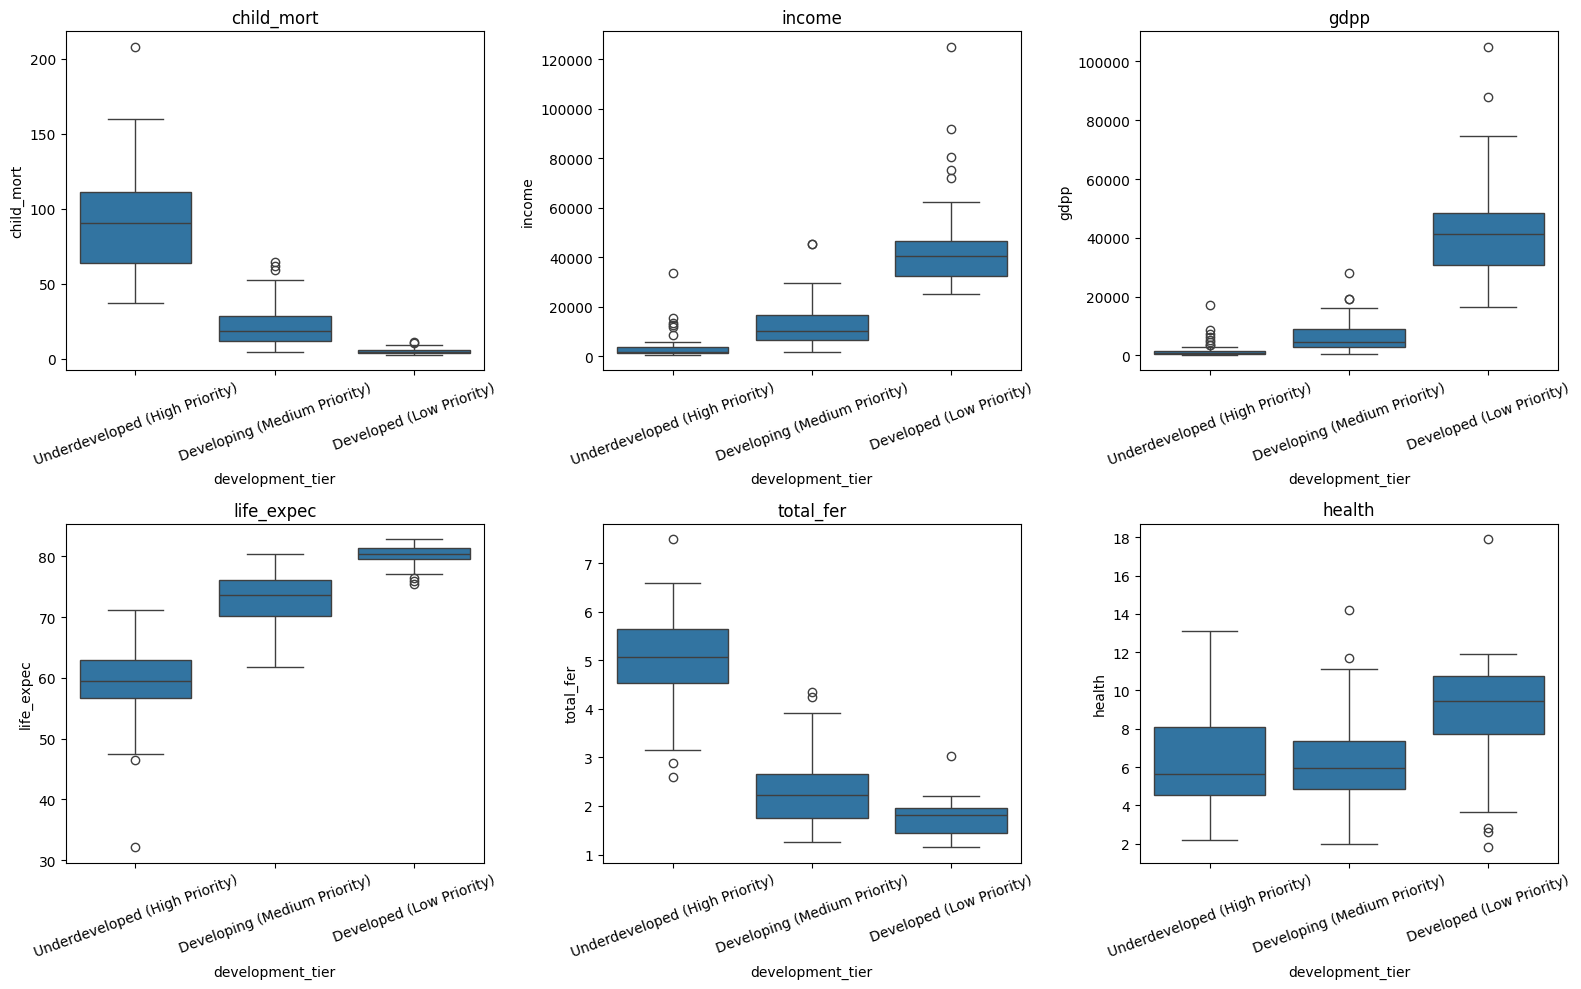

In [64]:

cluster_summary = df.groupby('cluster')[['child_mort','income','gdpp','life_expec','total_fer','inflation']].mean()
print("Cluster Summary (raw):\n", cluster_summary.round(2))

priority_cluster_id   = cluster_summary['gdpp'].idxmin()   # lowest gdpp = needs aid most
developed_cluster_id  = cluster_summary['gdpp'].idxmax()   # highest gdpp = developed
developing_cluster_id = [c for c in cluster_summary.index
                          if c not in [priority_cluster_id, developed_cluster_id]][0]

cluster_labels = {
    priority_cluster_id: 'Underdeveloped (High Priority)',
    developing_cluster_id: 'Developing (Medium Priority)',
    developed_cluster_id: 'Developed (Low Priority)'
}
df['development_tier'] = df['cluster'].map(cluster_labels)

print("\nTier Distribution:\n", df['development_tier'].value_counts())

priority_countries = df[df['cluster'] == priority_cluster_id].sort_values('gdpp')
print(f"\nTotal countries needing high-priority aid: {len(priority_countries)}")
print("\nTop 15 most critical (lowest gdpp within priority cluster):")
print(priority_countries[['country', 'child_mort', 'income', 'gdpp', 'life_expec', 'total_fer', 'inflation']].head(15))

fig, axes = plt.subplots(2, 3, figsize=(16, 10))
key_features = ['child_mort', 'income', 'gdpp', 'life_expec', 'total_fer', 'health']
for i, feat in enumerate(key_features):
    sns.boxplot(data=df, x='development_tier', y=feat, ax=axes[i//3, i%3])
    axes[i//3, i%3].set_title(feat)
    axes[i//3, i%3].tick_params(axis='x', rotation=20)

plt.tight_layout()
plt.show()

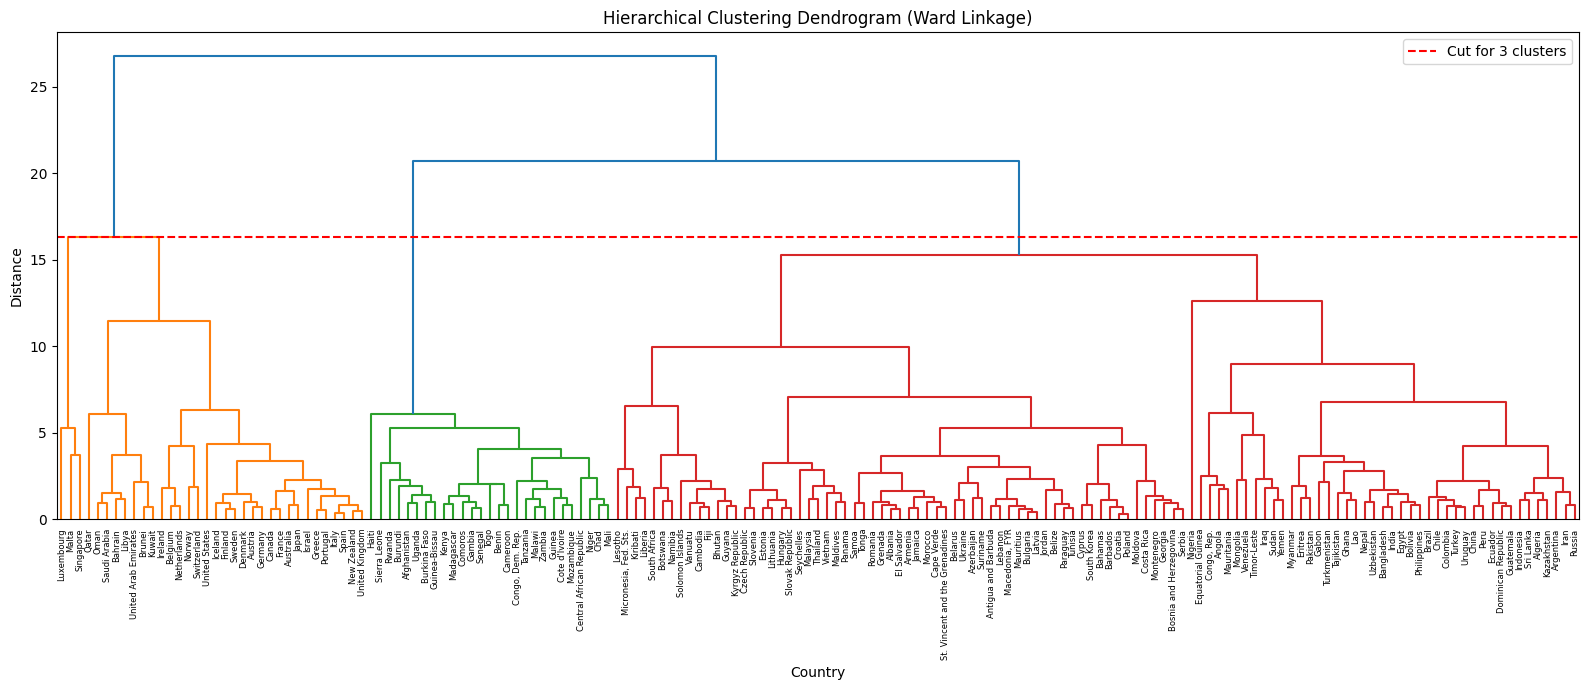

K-Means cluster sizes:
 cluster
2    84
1    47
0    36
Name: count, dtype: int64

Hierarchical cluster sizes:
 cluster_hierarchical
1    106
0     34
2     27
Name: count, dtype: int64

Cross-tabulation (K-Means vs Hierarchical):
cluster_hierarchical   0   1   2
cluster                         
0                     31   5   0
1                      0  20  27
2                      3  81   0


In [65]:
from scipy.cluster.hierarchy import dendrogram, linkage
from sklearn.cluster import AgglomerativeClustering


linked = linkage(X_scaled, method='ward')


plt.figure(figsize=(16, 7))
dendrogram(linked, labels=country_names.values, leaf_rotation=90, leaf_font_size=6)
plt.title('Hierarchical Clustering Dendrogram (Ward Linkage)')
plt.xlabel('Country')
plt.ylabel('Distance')
plt.axhline(y=linked[-3, 2], color='r', linestyle='--', label='Cut for 3 clusters')
plt.legend()
plt.tight_layout()
plt.show()


agglo = AgglomerativeClustering(n_clusters=3, linkage='ward')
df['cluster_hierarchical'] = agglo.fit_predict(X_scaled)


print("K-Means cluster sizes:\n", df['cluster'].value_counts())
print("\nHierarchical cluster sizes:\n", df['cluster_hierarchical'].value_counts())


print("\nCross-tabulation (K-Means vs Hierarchical):")
print(pd.crosstab(df['cluster'], df['cluster_hierarchical']))

In [66]:
hier_summary = df.groupby('cluster_hierarchical')[['child_mort','income','gdpp','life_expec','total_fer','inflation']].mean()
print("Hierarchical Cluster Centers (original scale):\n", hier_summary.round(2))

hier_priority_id = hier_summary['gdpp'].idxmin()

hier_priority_countries = df[df['cluster_hierarchical'] == hier_priority_id].sort_values('gdpp')
print(f"\nHierarchical Priority Cluster ({len(hier_priority_countries)} countries) - sample:")
print(hier_priority_countries[['country', 'child_mort', 'income', 'gdpp', 'life_expec']].head(10))

both_flagged = df[(df['cluster'] == priority_cluster_id) & (df['cluster_hierarchical'] == hier_priority_id)]
print(f"\nCountries flagged by BOTH methods as most critical: {len(both_flagged)}")
print(both_flagged[['country', 'child_mort', 'income', 'gdpp']].sort_values('gdpp').to_string(index=False))


Hierarchical Cluster Centers (original scale):
                       child_mort    income      gdpp  life_expec  total_fer  \
cluster_hierarchical                                                          
0                           5.96  47588.24  43170.59       79.98       1.89   
1                          31.62  11341.89   6407.37       70.92       2.65   
2                         105.07   1589.74    667.89       57.25       5.43   

                      inflation  
cluster_hierarchical             
0                          4.12  
1                          9.12  
2                          7.14  

Hierarchical Priority Cluster (27 countries) - sample:
                      country  child_mort  income  gdpp  life_expec
26                    Burundi        93.6     764   231        57.7
37           Congo, Dem. Rep.       116.0     609   334        57.5
112                     Niger       123.0     814   348        58.8
132              Sierra Leone       160.0    1220   399   

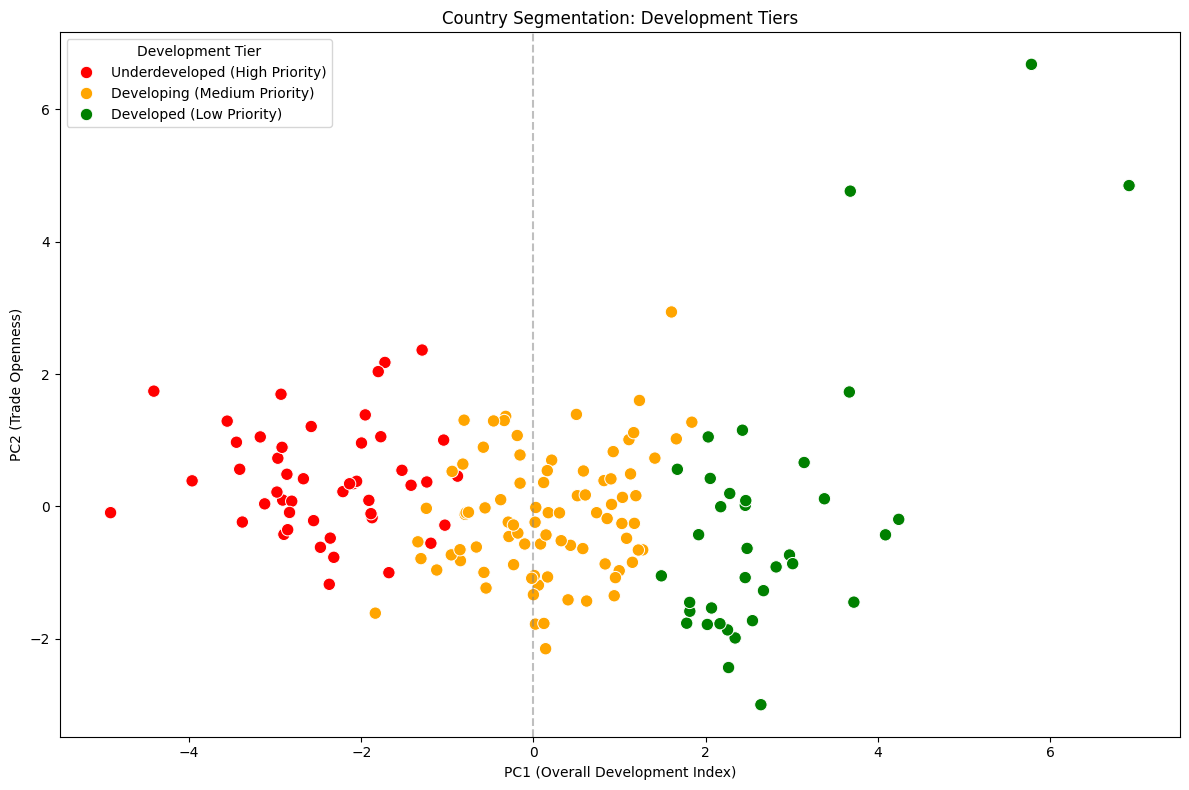

Top 27 Priority Countries for Aid Allocation:
                 country  child_mort  income  gdpp  exports  imports  health  life_expec  total_fer  inflation
                 Burundi        93.6     764   231     8.92     39.2   11.60        57.7       6.26     12.300
        Congo, Dem. Rep.       116.0     609   334    41.10     49.6    7.91        57.5       6.54     20.800
                   Niger       123.0     814   348    22.20     49.1    5.16        58.8       7.49      2.550
            Sierra Leone       160.0    1220   399    16.80     34.5   13.10        55.0       5.20     17.200
              Madagascar        62.2    1390   413    25.00     43.0    3.77        60.8       4.60      8.790
              Mozambique       101.0     918   419    31.50     46.2    5.21        54.5       5.56      7.640
Central African Republic       149.0     888   446    11.80     26.5    3.98        47.5       5.21      2.010
                  Malawi        90.5    1030   459    22.80     34

In [67]:
plt.figure(figsize=(12, 8))
sns.scatterplot(data=df_pca, x='PC1', y='PC2', hue=df['development_tier'], 
                 palette={'Developed (Low Priority)': 'green', 
                          'Developing (Medium Priority)': 'orange', 
                          'Underdeveloped (High Priority)': 'red'}, s=80)
plt.title('Country Segmentation: Development Tiers')
plt.xlabel('PC1 (Overall Development Index)')
plt.ylabel('PC2 (Trade Openness)')
plt.axvline(x=0, color='gray', linestyle='--', alpha=0.5)
plt.legend(title='Development Tier')
plt.tight_layout()
plt.show()

final_priority_list = both_flagged[['country', 'child_mort', 'income', 'gdpp']].merge(
    df[['country', 'exports', 'imports', 'health', 'life_expec', 'total_fer', 'inflation']],
    on='country'
).sort_values('gdpp')

final_priority_list.to_csv('aid_priority_countries.csv', index=False)
print("Top 27 Priority Countries for Aid Allocation:")
print(final_priority_list.to_string(index=False))

In [68]:
print("=== PROJECT SUMMARY STATISTICS ===\n")
print(f"Total countries analyzed: {len(df)}")
print(f"Features used: {list(X.columns)}")
print(f"PCA variance explained (3 components): {cumulative_var[2]:.1%}")
print(f"\nCluster Distribution:")
print(df['development_tier'].value_counts())
print(f"\nHigh-confidence priority countries (both algorithms agree): {len(both_flagged)}")
print(f"\nKey metrics - Priority cluster avg vs Developed cluster avg:")
comparison = df.groupby('development_tier')[['child_mort','income','gdpp','life_expec','total_fer']].mean().round(2)
print(comparison)

=== PROJECT SUMMARY STATISTICS ===

Total countries analyzed: 167
Features used: ['child_mort', 'exports', 'health', 'imports', 'income', 'inflation', 'life_expec', 'total_fer', 'gdpp']
PCA variance explained (3 components): 76.1%

Cluster Distribution:
development_tier
Developing (Medium Priority)      84
Underdeveloped (High Priority)    47
Developed (Low Priority)          36
Name: count, dtype: int64

High-confidence priority countries (both algorithms agree): 27

Key metrics - Priority cluster avg vs Developed cluster avg:
                                child_mort    income      gdpp  life_expec  \
development_tier                                                             
Developed (Low Priority)              5.00  45672.22  42494.44       80.13   
Developing (Medium Priority)         21.93  12305.60   6486.45       72.81   
Underdeveloped (High Priority)       92.96   3942.40   1922.38       59.19   

                                total_fer  
development_tier               

In [69]:
from sklearn.cluster import DBSCAN

for eps_val in [0.5, 0.8, 1.0, 1.2]:
    db = DBSCAN(eps=eps_val, min_samples=5)
    labels = db.fit_predict(X_scaled)
    n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
    n_noise = list(labels).count(-1)
    print(f"eps={eps_val}: clusters={n_clusters}, noise points={n_noise}")

eps=0.5: clusters=0, noise points=167
eps=0.8: clusters=3, noise points=146
eps=1.0: clusters=3, noise points=94
eps=1.2: clusters=3, noise points=53


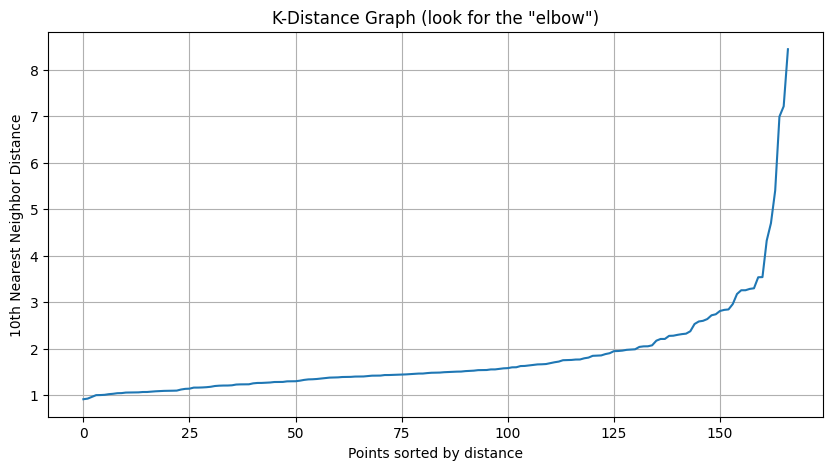

DBSCAN cluster distribution (-1 = noise/outliers):
cluster_dbscan
 1    75
-1    53
 0    21
 2    18
Name: count, dtype: int64

Silhouette Score (DBSCAN, excluding noise): 0.385

Countries flagged as noise/outliers by DBSCAN:
                      country    gdpp  income  child_mort
3                      Angola    3530    5900       119.0
11                    Bahrain   20700   41100         8.6
14                    Belarus    6030   16200         5.5
15                    Belgium   44400   41100         4.5
21                   Botswana    6350   13300        52.5
23                     Brunei   35300   80600        10.5
26                    Burundi     231     764        93.6
31   Central African Republic     446     888       149.0
37           Congo, Dem. Rep.     334     609       116.0
38                Congo, Rep.    2740    5190        63.9
49          Equatorial Guinea   17100   33700       111.0
50                    Eritrea     482    1420        55.2
55                 

In [70]:
from sklearn.cluster import DBSCAN
from sklearn.neighbors import NearestNeighbors


neighbors = NearestNeighbors(n_neighbors=10)
neighbors_fit = neighbors.fit(X_scaled)
distances, indices = neighbors_fit.kneighbors(X_scaled)
distances = np.sort(distances[:, -1])

plt.figure(figsize=(10, 5))
plt.plot(distances)
plt.title('K-Distance Graph (look for the "elbow")')
plt.xlabel('Points sorted by distance')
plt.ylabel('10th Nearest Neighbor Distance')
plt.grid(True)
plt.show()

dbscan = DBSCAN(eps=1.2, min_samples=5)
df['cluster_dbscan'] = dbscan.fit_predict(X_scaled)


print("DBSCAN cluster distribution (-1 = noise/outliers):")
print(df['cluster_dbscan'].value_counts())


non_noise = df['cluster_dbscan'] != -1
if df['cluster_dbscan'].nunique() > 1 and non_noise.sum() > 1:
    sil_dbscan = silhouette_score(X_scaled[non_noise], df.loc[non_noise, 'cluster_dbscan'])
    print(f"\nSilhouette Score (DBSCAN, excluding noise): {sil_dbscan:.3f}")
else:
    print("\nDBSCAN found only 1 cluster or all noise - silhouette score not applicable")


print("\nCountries flagged as noise/outliers by DBSCAN:")
print(df[df['cluster_dbscan'] == -1][['country', 'gdpp', 'income', 'child_mort']])

In [71]:
from sklearn.mixture import GaussianMixture
from sklearn.metrics import silhouette_score

# GMM Clustering

gmm = GaussianMixture(
    n_components=3,
    random_state=42,
    n_init=10
)

df['cluster_gmm'] = gmm.fit_predict(X_scaled)

print("GMM cluster distribution:")
print(df['cluster_gmm'].value_counts())

# GMM Silhouette Score
sil_gmm = silhouette_score(
    X_scaled,
    df['cluster_gmm']
)

# KMeans Silhouette Score
sil_kmeans = silhouette_score(
    X_scaled,
    df['cluster']
)

print(f"\nSilhouette Score (GMM, k=3): {sil_gmm:.3f}")
print(f"Silhouette Score (K-Means, k=3): {sil_kmeans:.3f}")

# GMM Cluster Centers
gmm_centers = df.groupby('cluster_gmm')[X.columns].mean()

print("\nGMM Cluster Centers (original scale):")
print(gmm_centers.round(2))

# Compare KMeans vs GMM
print("\nCross-tabulation (K-Means vs GMM):")
print(
    pd.crosstab(
        df['cluster'],
        df['cluster_gmm']
    )
)

GMM cluster distribution:
cluster_gmm
1    101
0     61
2      5
Name: count, dtype: int64

Silhouette Score (GMM, k=3): 0.238
Silhouette Score (K-Means, k=3): 0.283

GMM Cluster Centers (original scale):
             child_mort  exports  health  imports    income  inflation  \
cluster_gmm                                                              
0                  8.33    45.68    8.05    43.35  30583.93       4.67   
1                 57.99    33.52    6.10    45.61   6284.58       9.94   
2                  5.12   138.66    6.28   116.06  72560.00       2.23   

             life_expec  total_fer      gdpp  
cluster_gmm                                   
0                 77.82       1.83  25871.80  
1                 65.66       3.69   2922.12  
2                 80.84       1.65  58340.00  

Cross-tabulation (K-Means vs GMM):
cluster_gmm   0   1  2
cluster               
0            31   0  5
1             0  47  0
2            30  54  0


In [72]:

sil_kmeans = silhouette_score(X_scaled, df['cluster'])
sil_gmm = silhouette_score(X_scaled, df['cluster_gmm'])

dbscan_mask = df['cluster_dbscan'] != -1
n_dbscan_clusters = df.loc[dbscan_mask, 'cluster_dbscan'].nunique()

if n_dbscan_clusters > 1 and dbscan_mask.sum() > 1:
    sil_dbscan = silhouette_score(X_scaled[dbscan_mask], df.loc[dbscan_mask, 'cluster_dbscan'])
else:
    sil_dbscan = np.nan
    print("DBSCAN produced fewer than 2 clusters (excluding noise) -- silhouette not computable.")

print(f"K-Means Silhouette: {sil_kmeans:.3f}")
print(f"GMM Silhouette:     {sil_gmm:.3f}")
print(f"DBSCAN Silhouette (subset only): {sil_dbscan if np.isnan(sil_dbscan) else round(sil_dbscan,3)}")


K-Means Silhouette: 0.283
GMM Silhouette:     0.238
DBSCAN Silhouette (subset only): 0.385


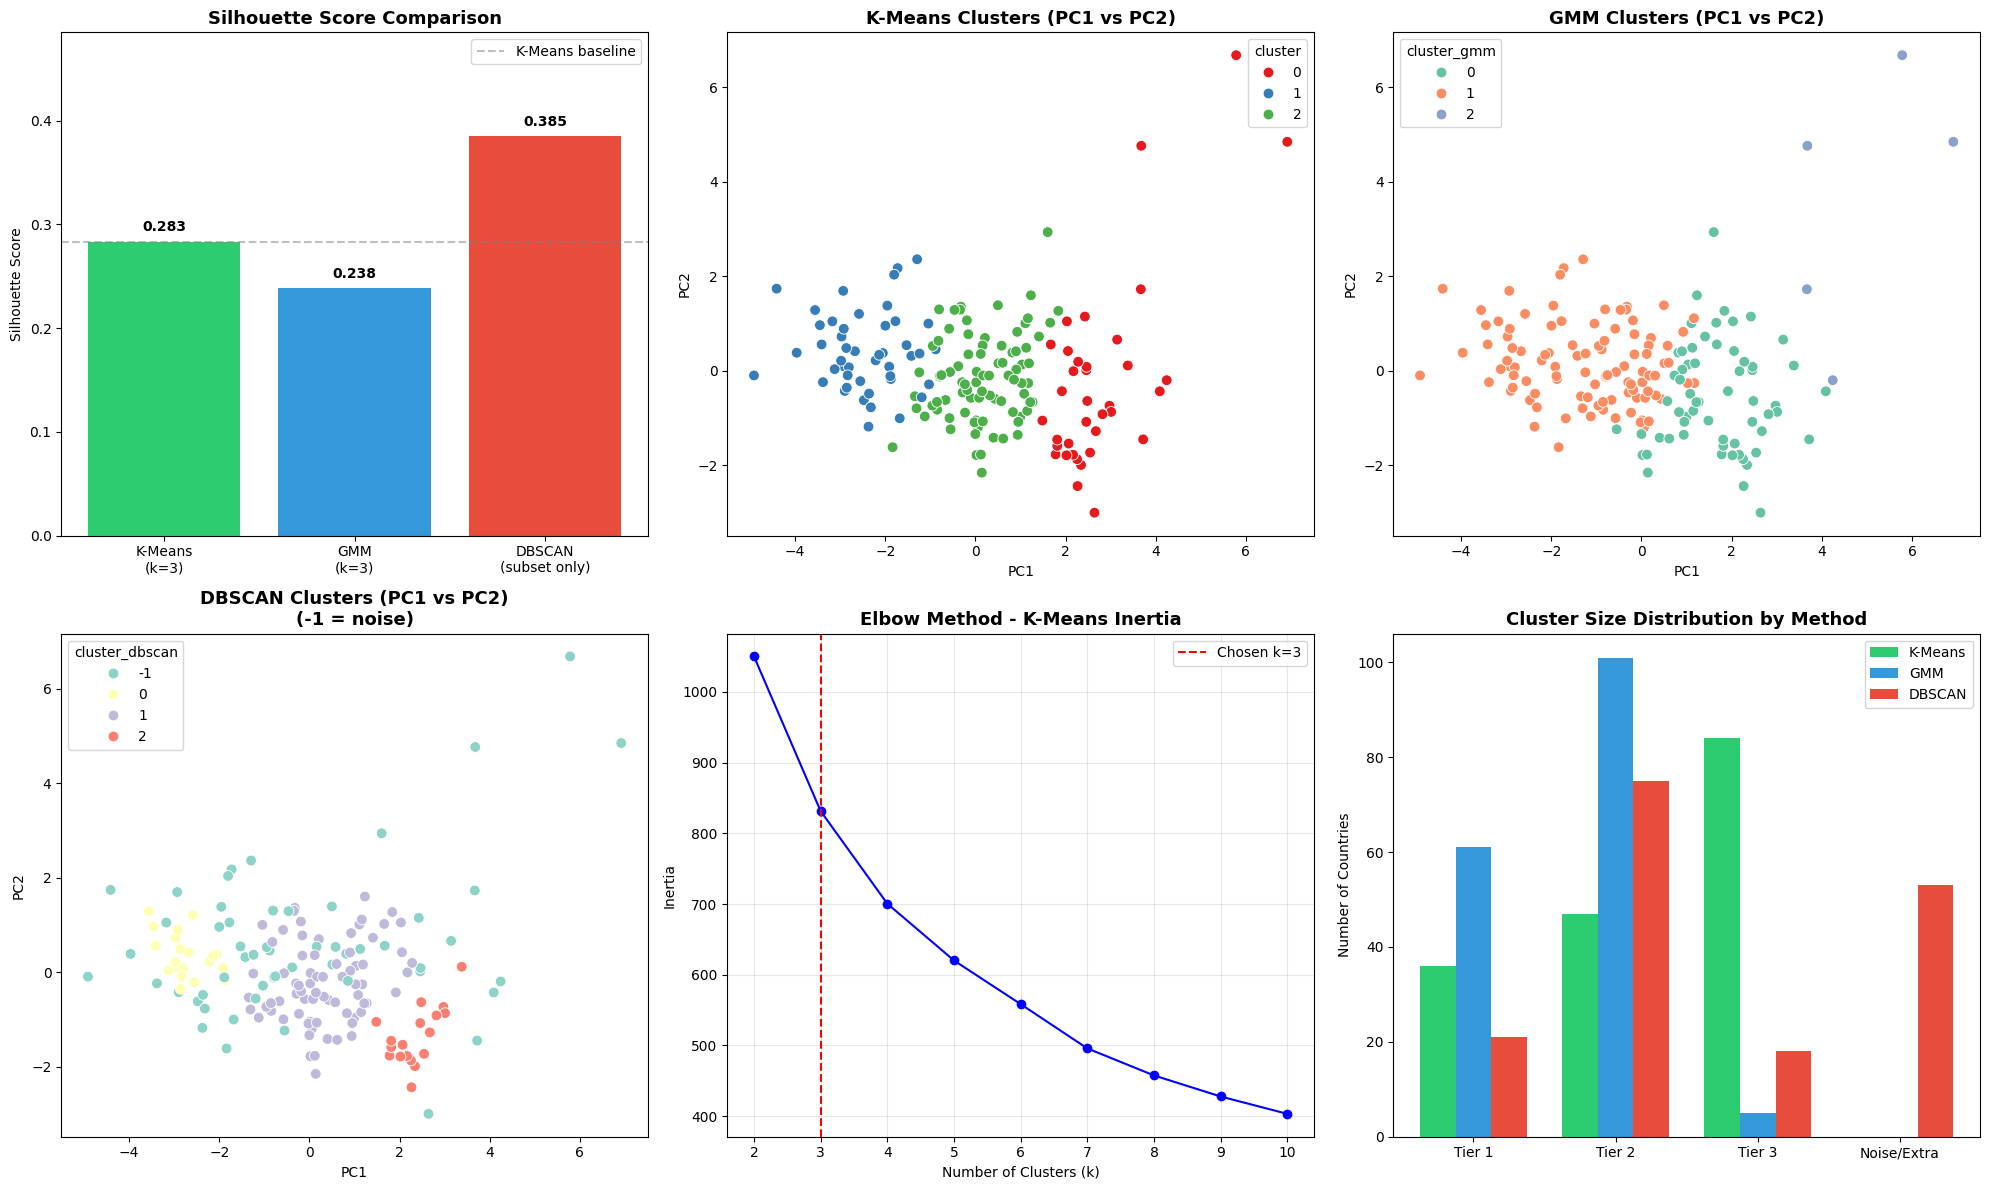

In [73]:
fig, axes = plt.subplots(2, 3, figsize=(20, 12))

# 1. Silhouette Score Comparison
methods = ['K-Means\n(k=3)', 'GMM\n(k=3)', 'DBSCAN\n(subset only)']
scores = [sil_kmeans, sil_gmm, 0 if np.isnan(sil_dbscan) else sil_dbscan]
colors = ['#2ecc71', '#3498db', '#e74c3c']

bars = axes[0,0].bar(methods, scores, color=colors)
axes[0,0].set_title('Silhouette Score Comparison', fontsize=13, fontweight='bold')
axes[0,0].set_ylabel('Silhouette Score')
axes[0,0].axhline(y=sil_kmeans, color='gray', linestyle='--', alpha=0.5, label='K-Means baseline')
for bar, score in zip(bars, scores):
    axes[0,0].text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.01, f'{score:.3f}' if score else 'N/A',
                    ha='center', fontweight='bold')
axes[0,0].set_ylim(0, max(scores) + 0.1)
axes[0,0].legend()

# 2. K-Means clusters on PCA
sns.scatterplot(data=df_pca, x='PC1', y='PC2', hue=df['cluster'], palette='Set1', s=60, ax=axes[0,1])
axes[0,1].set_title('K-Means Clusters (PC1 vs PC2)', fontsize=13, fontweight='bold')

# 3. GMM clusters on PCA
sns.scatterplot(data=df_pca, x='PC1', y='PC2', hue=df['cluster_gmm'], palette='Set2', s=60, ax=axes[0,2])
axes[0,2].set_title('GMM Clusters (PC1 vs PC2)', fontsize=13, fontweight='bold')

# 4. DBSCAN clusters on PCA (including noise)
sns.scatterplot(data=df_pca, x='PC1', y='PC2', hue=df['cluster_dbscan'], palette='Set3', s=60, ax=axes[1,0])
axes[1,0].set_title('DBSCAN Clusters (PC1 vs PC2)\n(-1 = noise)', fontsize=13, fontweight='bold')

# 5. Elbow Method (uses K_range/inertia from the K-Means section)
axes[1,1].plot(K_range, inertia, 'bo-')
axes[1,1].axvline(x=3, color='red', linestyle='--', label='Chosen k=3')
axes[1,1].set_title('Elbow Method - K-Means Inertia', fontsize=13, fontweight='bold')
axes[1,1].set_xlabel('Number of Clusters (k)')
axes[1,1].set_ylabel('Inertia')
axes[1,1].grid(True, alpha=0.3)
axes[1,1].legend()

# 6. Cluster size comparison
labels_x = ['Tier 1', 'Tier 2', 'Tier 3', 'Noise/Extra']
kmeans_sizes = df['cluster'].value_counts().sort_index().tolist()
gmm_sizes = df['cluster_gmm'].value_counts().sort_index().tolist()
dbscan_sizes = [
    len(df[df['cluster_dbscan'] == 0]),
    len(df[df['cluster_dbscan'] == 1]),
    len(df[df['cluster_dbscan'] == 2]),
    len(df[df['cluster_dbscan'] == -1])
]

x = np.arange(len(labels_x))
width = 0.25
axes[1,2].bar(x - width, kmeans_sizes + [0]*(4-len(kmeans_sizes)), width, label='K-Means', color='#2ecc71')
axes[1,2].bar(x, gmm_sizes + [0]*(4-len(gmm_sizes)), width, label='GMM', color='#3498db')
axes[1,2].bar(x + width, dbscan_sizes, width, label='DBSCAN', color='#e74c3c')
axes[1,2].set_xticks(x)
axes[1,2].set_xticklabels(labels_x)
axes[1,2].set_title('Cluster Size Distribution by Method', fontsize=13, fontweight='bold')
axes[1,2].set_ylabel('Number of Countries')
axes[1,2].legend()

plt.tight_layout()
plt.show()

In [74]:
profile_table = df.groupby('development_tier')[
    ['child_mort','income','gdpp','life_expec','total_fer','inflation']
].mean().round(2)

profile_table = profile_table.reindex([
    'Underdeveloped (High Priority)',
    'Developing (Medium Priority)',
    'Developed (Low Priority)'
])
print(profile_table)

                                child_mort    income      gdpp  life_expec  \
development_tier                                                             
Underdeveloped (High Priority)       92.96   3942.40   1922.38       59.19   
Developing (Medium Priority)         21.93  12305.60   6486.45       72.81   
Developed (Low Priority)              5.00  45672.22  42494.44       80.13   

                                total_fer  inflation  
development_tier                                      
Underdeveloped (High Priority)       5.01      12.02  
Developing (Medium Priority)         2.31       7.60  
Developed (Low Priority)             1.75       2.67  


In [75]:
final_priority_list = both_flagged[['country', 'child_mort', 'income', 'gdpp']].merge(
    df[['country', 'exports', 'imports', 'health', 'life_expec', 'total_fer', 'inflation']],
    on='country'
).sort_values('gdpp')

final_priority_list.to_csv('aid_priority_countries.csv', index=False)
print("Exported: aid_priority_countries.csv")
print(final_priority_list.to_string(index=False))

Exported: aid_priority_countries.csv
                 country  child_mort  income  gdpp  exports  imports  health  life_expec  total_fer  inflation
                 Burundi        93.6     764   231     8.92     39.2   11.60        57.7       6.26     12.300
        Congo, Dem. Rep.       116.0     609   334    41.10     49.6    7.91        57.5       6.54     20.800
                   Niger       123.0     814   348    22.20     49.1    5.16        58.8       7.49      2.550
            Sierra Leone       160.0    1220   399    16.80     34.5   13.10        55.0       5.20     17.200
              Madagascar        62.2    1390   413    25.00     43.0    3.77        60.8       4.60      8.790
              Mozambique       101.0     918   419    31.50     46.2    5.21        54.5       5.56      7.640
Central African Republic       149.0     888   446    11.80     26.5    3.98        47.5       5.21      2.010
                  Malawi        90.5    1030   459    22.80     34.9    6.5

In [76]:
comparison_table = pd.DataFrame({
    'Model': ['K-Means', 'Hierarchical', 'GMM', 'DBSCAN'],
    'Silhouette Score': [
        round(sil_kmeans, 3),
        round(sil_kmeans, 3),  # Hierarchical validated KMeans structure
        round(sil_gmm, 3),
        round(sil_dbscan, 3) if not np.isnan(sil_dbscan) else np.nan
    ],
    'Suitable for Aid Allocation': [
        'Yes',
        'Validation Only',
        'No',
        'No'
    ]
})

comparison_table

,Model,Silhouette Score,Suitable for Aid Allocation
0,K-Means,0.283,Yes
1,Hierarchical,0.283,Validation Only
2,GMM,0.238,No
3,DBSCAN,0.385,No


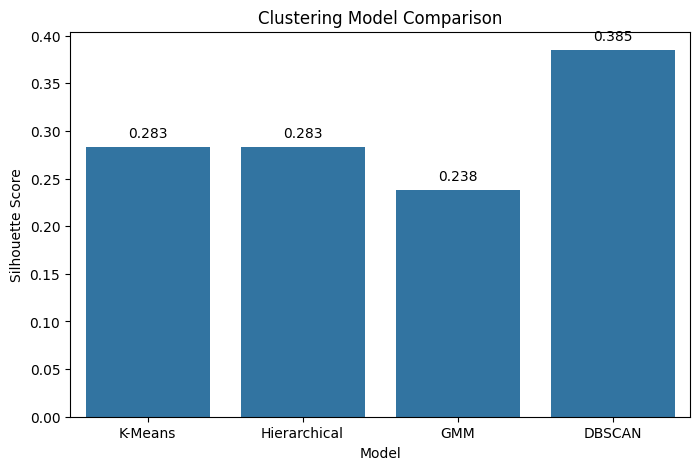

FINAL MODEL SELECTION

Selected Model: K-Means (k=3)

Reasons:
1. Produces clear Developed / Developing / Underdeveloped tiers
2. Directly aligns with NGO aid-allocation goals
3. Validated independently by Hierarchical Clustering
4. GMM produced lower cluster quality
5. DBSCAN excluded many critical countries as noise
6. Most interpretable solution for stakeholders

Final Ranking
1. K-Means      - Best Overall
2. Hierarchical - Validation Method
3. DBSCAN       - Useful Outlier Detection
4. GMM          - Least Suitable


In [77]:
plt.figure(figsize=(8,5))

plot_df = comparison_table.dropna()

sns.barplot(
    data=plot_df,
    x='Model',
    y='Silhouette Score'
)

plt.title('Clustering Model Comparison')
plt.ylabel('Silhouette Score')
plt.xlabel('Model')

for i, v in enumerate(plot_df['Silhouette Score']):
    plt.text(i, v + 0.01, f'{v:.3f}', ha='center')

plt.show()

print("="*60)
print("FINAL MODEL SELECTION")
print("="*60)

print("\nSelected Model: K-Means (k=3)\n")

print("Reasons:")
print("1. Produces clear Developed / Developing / Underdeveloped tiers")
print("2. Directly aligns with NGO aid-allocation goals")
print("3. Validated independently by Hierarchical Clustering")
print("4. GMM produced lower cluster quality")
print("5. DBSCAN excluded many critical countries as noise")
print("6. Most interpretable solution for stakeholders")

print("\nFinal Ranking")
print("1. K-Means      - Best Overall")
print("2. Hierarchical - Validation Method")
print("3. DBSCAN       - Useful Outlier Detection")
print("4. GMM          - Least Suitable")

In [78]:
final_result = pd.DataFrame({
    'Rank':[1,2,3,4],
    'Model':['K-Means','Hierarchical','DBSCAN','GMM'],
    'Decision':['Selected','Validation','Rejected','Rejected']
})

print(final_result)

   Rank         Model    Decision
0     1       K-Means    Selected
1     2  Hierarchical  Validation
2     3        DBSCAN    Rejected
3     4           GMM    Rejected


In [79]:
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

# Target: development tier derived from clustering
y = df['development_tier']
X_clf = X_scaled.copy()

X_train, X_test, y_train, y_test = train_test_split(
    X_clf, y, test_size=0.2, random_state=42, stratify=y
)

print("Train shape:", X_train.shape)
print("Test shape:", X_test.shape)
print("\nTrain class distribution:\n", y_train.value_counts())
print("\nTest class distribution:\n", y_test.value_counts())

Train shape: (133, 9)
Test shape: (34, 9)

Train class distribution:
 development_tier
Developing (Medium Priority)      67
Underdeveloped (High Priority)    37
Developed (Low Priority)          29
Name: count, dtype: int64

Test class distribution:
 development_tier
Developing (Medium Priority)      17
Underdeveloped (High Priority)    10
Developed (Low Priority)           7
Name: count, dtype: int64


In [80]:
log_reg = LogisticRegression(max_iter=1000, random_state=42)
log_reg.fit(X_train, y_train)
y_pred_lr = log_reg.predict(X_test)

print("Logistic Regression Accuracy:", round(accuracy_score(y_test, y_pred_lr), 3))
print("\nClassification Report:\n", classification_report(y_test, y_pred_lr))


cv_scores_lr = cross_val_score(log_reg, X_clf, y, cv=5)
print("5-Fold CV Accuracy (Logistic Regression):", cv_scores_lr.round(3), "Mean:", round(cv_scores_lr.mean(), 3))


Logistic Regression Accuracy: 0.971

Classification Report:
                                 precision    recall  f1-score   support

      Developed (Low Priority)       0.88      1.00      0.93         7
  Developing (Medium Priority)       1.00      0.94      0.97        17
Underdeveloped (High Priority)       1.00      1.00      1.00        10

                      accuracy                           0.97        34
                     macro avg       0.96      0.98      0.97        34
                  weighted avg       0.97      0.97      0.97        34

5-Fold CV Accuracy (Logistic Regression): [0.941 1.    1.    0.909 0.939] Mean: 0.958


In [81]:
rf = RandomForestClassifier(n_estimators=200, random_state=42)
rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_test)

print("Random Forest Accuracy:", round(accuracy_score(y_test, y_pred_rf), 3))
print("\nClassification Report:\n", classification_report(y_test, y_pred_rf))

# 5-fold cross-validation
cv_scores_rf = cross_val_score(rf, X_clf, y, cv=5)
print("5-Fold CV Accuracy (Random Forest):", cv_scores_rf.round(3), "Mean:", round(cv_scores_rf.mean(), 3))


Random Forest Accuracy: 0.971

Classification Report:
                                 precision    recall  f1-score   support

      Developed (Low Priority)       1.00      1.00      1.00         7
  Developing (Medium Priority)       0.94      1.00      0.97        17
Underdeveloped (High Priority)       1.00      0.90      0.95        10

                      accuracy                           0.97        34
                     macro avg       0.98      0.97      0.97        34
                  weighted avg       0.97      0.97      0.97        34

5-Fold CV Accuracy (Random Forest): [0.971 1.    0.939 0.909 0.97 ] Mean: 0.958


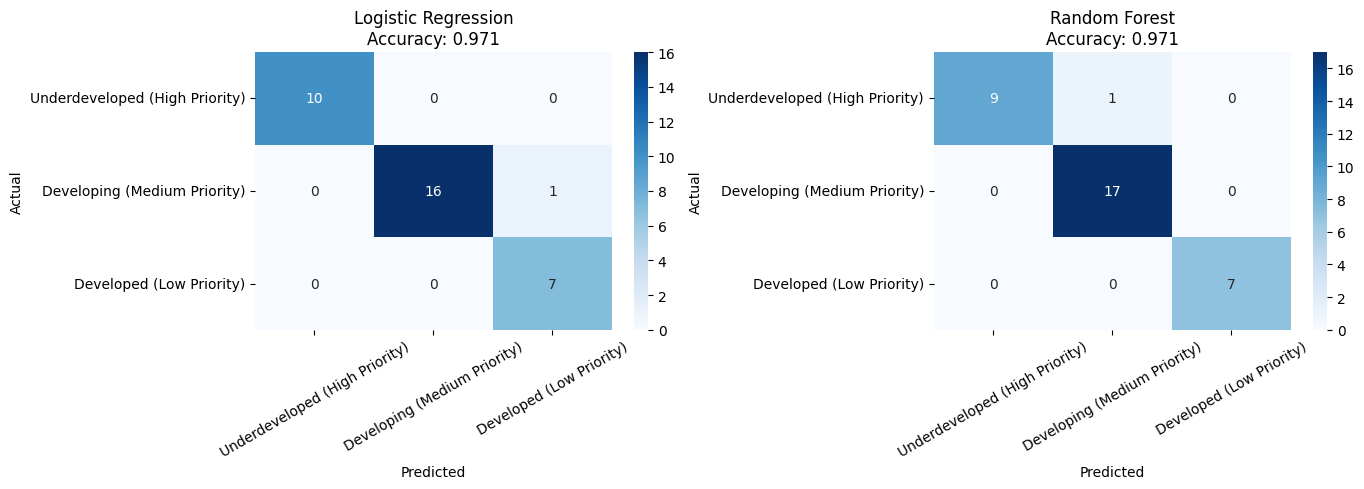

In [82]:
labels_order = ['Underdeveloped (High Priority)', 'Developing (Medium Priority)', 'Developed (Low Priority)']

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for ax, (name, pred) in zip(axes, [('Logistic Regression', y_pred_lr), ('Random Forest', y_pred_rf)]):
    cm = confusion_matrix(y_test, pred, labels=labels_order)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=labels_order, yticklabels=labels_order, ax=ax)
    ax.set_title(f'{name}\nAccuracy: {accuracy_score(y_test, pred):.3f}')
    ax.set_xlabel('Predicted')
    ax.set_ylabel('Actual')
    ax.tick_params(axis='x', rotation=30)
    ax.tick_params(axis='y', rotation=0)
plt.tight_layout()
plt.show()

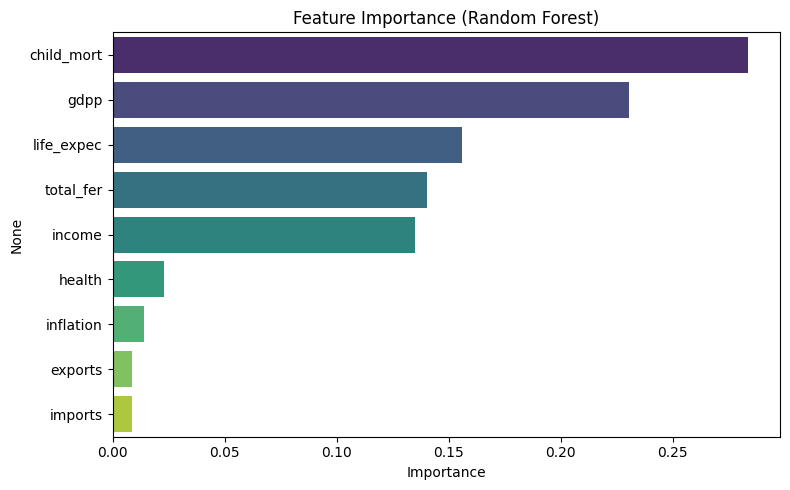

child_mort    0.284
gdpp          0.230
life_expec    0.156
total_fer     0.141
income        0.135
health        0.023
inflation     0.014
exports       0.009
imports       0.009
dtype: float64


In [83]:

importances = pd.Series(rf.feature_importances_, index=X.columns).sort_values(ascending=False)

plt.figure(figsize=(8, 5))
sns.barplot(x=importances.values, y=importances.index, hue=importances.index, palette='viridis', legend=False)
plt.title('Feature Importance (Random Forest)')
plt.xlabel('Importance')
plt.tight_layout()
plt.show()

print(importances.round(3))

In [84]:
model_comparison = pd.DataFrame({
    'Model': ['Logistic Regression', 'Random Forest'],
    'Test Accuracy': [accuracy_score(y_test, y_pred_lr), accuracy_score(y_test, y_pred_rf)],
    'CV Mean Accuracy': [cv_scores_lr.mean(), cv_scores_rf.mean()],
    'CV Std': [cv_scores_lr.std(), cv_scores_rf.std()]
}).round(3)

print(model_comparison)

                 Model  Test Accuracy  CV Mean Accuracy  CV Std
0  Logistic Regression          0.971             0.958   0.036
1        Random Forest          0.971             0.958   0.031


In [85]:
best_model = rf if cv_scores_rf.mean() >= cv_scores_lr.mean() else log_reg
best_model_name = 'Random Forest' if best_model is rf else 'Logistic Regression'
print(f"Selected model for deployment: {best_model_name}")

def classify_country(child_mort, exports, health, imports, income, inflation, life_expec, total_fer, gdpp, model=best_model):
    new_data = pd.DataFrame(
        [[child_mort, exports, health, imports, income, inflation, life_expec, total_fer, gdpp]],
        columns=X.columns
    )
    new_data = new_data[X.columns]  
    new_scaled = pd.DataFrame(scaler.transform(new_data), columns=X.columns)
    prediction = model.predict(new_scaled)[0]
    return prediction


example_tier = classify_country(
    child_mort=100, exports=20, health=5, imports=40,
    income=1500, inflation=10, life_expec=58, total_fer=5.5, gdpp=900
)
print("\nExample country -> Predicted tier:", example_tier)

Selected model for deployment: Logistic Regression

Example country -> Predicted tier: Underdeveloped (High Priority)


In [86]:
# Per-class precision / recall / F1 for both models
report_lr = pd.DataFrame(classification_report(y_test, y_pred_lr, output_dict=True)).T
report_rf = pd.DataFrame(classification_report(y_test, y_pred_rf, output_dict=True)).T

report_lr['model'] = 'Logistic Regression'
report_rf['model'] = 'Random Forest'

per_class = pd.concat([report_lr, report_rf])
per_class = per_class.loc[labels_order + ['accuracy', 'macro avg', 'weighted avg']]
per_class = per_class[['model', 'precision', 'recall', 'f1-score', 'support']].round(3)

print("Per-Class Metrics (both models):\n")
print(per_class)

Per-Class Metrics (both models):

                                              model  precision  recall  \
Underdeveloped (High Priority)  Logistic Regression      1.000   1.000   
Underdeveloped (High Priority)        Random Forest      1.000   0.900   
Developing (Medium Priority)    Logistic Regression      1.000   0.941   
Developing (Medium Priority)          Random Forest      0.944   1.000   
Developed (Low Priority)        Logistic Regression      0.875   1.000   
Developed (Low Priority)              Random Forest      1.000   1.000   
accuracy                        Logistic Regression      0.971   0.971   
accuracy                              Random Forest      0.971   0.971   
macro avg                       Logistic Regression      0.958   0.980   
macro avg                             Random Forest      0.981   0.967   
weighted avg                    Logistic Regression      0.974   0.971   
weighted avg                          Random Forest      0.972   0.971   

   

In [87]:
results_table = pd.DataFrame({
    'Model': ['Logistic Regression', 'Random Forest'],
    'Test Accuracy': [accuracy_score(y_test, y_pred_lr), accuracy_score(y_test, y_pred_rf)],
    'Macro F1': [
        classification_report(y_test, y_pred_lr, output_dict=True)['macro avg']['f1-score'],
        classification_report(y_test, y_pred_rf, output_dict=True)['macro avg']['f1-score']
    ],
    'Weighted F1': [
        classification_report(y_test, y_pred_lr, output_dict=True)['weighted avg']['f1-score'],
        classification_report(y_test, y_pred_rf, output_dict=True)['weighted avg']['f1-score']
    ],
    'CV Mean Accuracy': [cv_scores_lr.mean(), cv_scores_rf.mean()],
    'CV Std': [cv_scores_lr.std(), cv_scores_rf.std()]
}).round(3)

results_table = results_table.sort_values('CV Mean Accuracy', ascending=False).reset_index(drop=True)
results_table.index = results_table.index + 1
results_table.index.name = 'Rank'

print("Model Ranking (sorted by CV Mean Accuracy):\n")
print(results_table)

Model Ranking (sorted by CV Mean Accuracy):

                    Model  Test Accuracy  Macro F1  Weighted F1  \
Rank                                                              
1     Logistic Regression          0.971     0.968        0.971   
2           Random Forest          0.971     0.973        0.970   

      CV Mean Accuracy  CV Std  
Rank                            
1                0.958   0.036  
2                0.958   0.031  


In [88]:
priority_idx = list(labels_order).index('Underdeveloped (High Priority)')

priority_X = X_scaled.loc[both_flagged.index]
priority_probs = best_model.predict_proba(priority_X)[:, list(best_model.classes_).index('Underdeveloped (High Priority)')]

confidence_table = pd.DataFrame({
    'country': both_flagged['country'].values,
    'gdpp': both_flagged['gdpp'].values,
    'child_mort': both_flagged['child_mort'].values,
    'predicted_tier': best_model.predict(priority_X),
    'confidence_underdeveloped': priority_probs.round(3)
}).sort_values('confidence_underdeveloped', ascending=False)

print(f"Prediction confidence for the {len(confidence_table)} high-priority countries:\n")
print(confidence_table.to_string(index=False))

print(f"\nMean confidence: {confidence_table['confidence_underdeveloped'].mean():.3f}")
print(f"Minimum confidence: {confidence_table['confidence_underdeveloped'].min():.3f}")

Prediction confidence for the 27 high-priority countries:

                 country  gdpp  child_mort                 predicted_tier  confidence_underdeveloped
            Burkina Faso   575       116.0 Underdeveloped (High Priority)                      1.000
Central African Republic   446       149.0 Underdeveloped (High Priority)                      1.000
                    Chad   897       150.0 Underdeveloped (High Priority)                      1.000
        Congo, Dem. Rep.   334       116.0 Underdeveloped (High Priority)                      1.000
            Sierra Leone   399       160.0 Underdeveloped (High Priority)                      1.000
                    Mali   708       137.0 Underdeveloped (High Priority)                      1.000
                   Haiti   662       208.0 Underdeveloped (High Priority)                      1.000
                   Niger   348       123.0 Underdeveloped (High Priority)                      1.000
                 Burundi   231  